# Supply Chain Service Level Tracking Analysis

In [1]:
# Dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Cleaning

In [2]:
# Load data
customers = pd.read_csv("G:/Other computers/Laptop - GoogleDrive/data analytics/projects/supply chain _ codebasics/analysis_dataset/dim_customers.csv")
date = pd.read_csv("G:/Other computers/Laptop - GoogleDrive/data analytics/projects/supply chain _ codebasics/analysis_dataset/dim_date.csv")
products = pd.read_csv("G:/Other computers/Laptop - GoogleDrive/data analytics/projects/supply chain _ codebasics/analysis_dataset/dim_products.csv")
targets = pd.read_csv("G:/Other computers/Laptop - GoogleDrive/data analytics/projects/supply chain _ codebasics/analysis_dataset/dim_targets_orders.csv")
order_lines = pd.read_csv("G:/Other computers/Laptop - GoogleDrive/data analytics/projects/supply chain _ codebasics/analysis_dataset/fact_order_lines.csv")


### Preview data set

In [3]:
customers.head(3)

,customer_id,customer_name,city
0,789201,Rel Fresh,Surat
1,789202,Rel Fresh,Ahmedabad
2,789203,Rel Fresh,Vadodara


In [4]:
date.head(3)

,date,mmm_yy,week_no
0,01-Apr-22,01-Apr-22,W 14
1,03-Apr-22,01-Apr-22,W 15
2,04-Apr-22,01-Apr-22,W 15


In [5]:
products.head(3)

,product_id,product_name,category
0,25891101,AM Milk 500,Dairy
1,25891102,AM Milk 250,Dairy
2,25891103,AM Milk 100,Dairy


In [6]:
targets.head(3)

,customer_id,ontime_target%,infull_target%,otif_target%
0,789201,87,81,70
1,789202,85,81,69
2,789203,92,76,70


In [7]:
order_lines.head(3)

,order_id,order_placement_date,customer_id,product_id,order_qty,agreed_delivery_date,actual_delivery_date,delivery_qty
0,FMR34203601,"Tuesday, March 1, 2022",789203,25891601,110,"Friday, March 4, 2022","Friday, March 4, 2022",110
1,FMR32320302,"Tuesday, March 1, 2022",789320,25891203,347,"Wednesday, March 2, 2022","Wednesday, March 2, 2022",347
2,FMR33320501,"Tuesday, March 1, 2022",789320,25891203,187,"Thursday, March 3, 2022","Thursday, March 3, 2022",150


### Standardise column names for all tables

In [8]:
# Standardise column names
for df in [customers, date, products, targets, order_lines]:
    df.columns = df.columns.str.lower().str.strip()

### Validate **`customers`** table
- data types
- missing values
- duplicates

In [9]:
customers.dtypes

customer_id       int64
customer_name    object
city             object
dtype: object

In [10]:
customers.isnull().sum()

customer_id      0
customer_name    0
city             0
dtype: int64

In [11]:
customers.duplicated().sum()

np.int64(0)

In [12]:
customers.duplicated(subset=['customer_id', 'customer_name', 'city']).sum()

np.int64(0)

### Validate **`date`** table
- data types
- missing values
- duplicates

In [13]:
date.dtypes

date       object
mmm_yy     object
week_no    object
dtype: object

#### parse datetime data type for columns:
- date
- mmm-yy

In [14]:
# Convert date column
date['date'] = pd.to_datetime(date['date'], format='%d-%b-%y')

# Convert mmm_yy to datetime (month-level)
date['mmm_yy'] = pd.to_datetime(date['mmm_yy'], format='%d-%b-%y')

# week_no stays as text
date['week_no'] = date['week_no'].astype('string')

date.dtypes

date       datetime64[ns]
mmm_yy     datetime64[ns]
week_no    string[python]
dtype: object

In [15]:
date.head(3)

,date,mmm_yy,week_no
0,2022-04-01,2022-04-01,W 14
1,2022-04-03,2022-04-01,W 15
2,2022-04-04,2022-04-01,W 15


In [16]:
date.isnull().sum()

date       0
mmm_yy     0
week_no    0
dtype: int64

In [17]:
date.duplicated().sum()

np.int64(0)

### Validate **`products`** table
- data types
- missing values
- duplicates

In [18]:
products.dtypes

product_id       int64
product_name    object
category        object
dtype: object

In [19]:
products.isnull().sum()

product_id      0
product_name    0
category        0
dtype: int64

In [20]:
products.duplicated(subset=['product_id', 'product_name']).sum()

np.int64(0)

### Validate **`targets`** table
- data types
- missing values
- duplicates

In [21]:
targets.dtypes

customer_id       int64
ontime_target%    int64
infull_target%    int64
otif_target%      int64
dtype: object

In [22]:
targets.isnull().sum()

customer_id       0
ontime_target%    0
infull_target%    0
otif_target%      0
dtype: int64

In [23]:
targets.duplicated(subset=['customer_id']).sum()

np.int64(0)

In [24]:
# Adjust column names
targets = targets.rename(columns={
    'ontime_target%': 'ontime_target_pct',
    'infull_target%': 'infull_target_pct',
    'otif_target%': 'otif_target_pct'
})

In [25]:
targets.columns.to_list()

['customer_id', 'ontime_target_pct', 'infull_target_pct', 'otif_target_pct']

### Validate **`order_lines`** table
- data types
- missing values
- duplicates

In [26]:
order_lines.dtypes

order_id                object
order_placement_date    object
customer_id              int64
product_id               int64
order_qty                int64
agreed_delivery_date    object
actual_delivery_date    object
delivery_qty             int64
dtype: object

#### parse datetime data type for columns:
- order_placement_date
- agreed_delivery_date
- actual_delivery_date

In [27]:
order_lines['order_placement_date'] = pd.to_datetime(order_lines['order_placement_date'])
order_lines['agreed_delivery_date'] = pd.to_datetime(order_lines['agreed_delivery_date'])
order_lines['actual_delivery_date'] = pd.to_datetime(order_lines['actual_delivery_date'])

order_lines.dtypes

order_id                        object
order_placement_date    datetime64[ns]
customer_id                      int64
product_id                       int64
order_qty                        int64
agreed_delivery_date    datetime64[ns]
actual_delivery_date    datetime64[ns]
delivery_qty                     int64
dtype: object

In [28]:
order_lines.head(3)

,order_id,order_placement_date,customer_id,product_id,order_qty,agreed_delivery_date,actual_delivery_date,delivery_qty
0,FMR34203601,2022-03-01,789203,25891601,110,2022-03-04,2022-03-04,110
1,FMR32320302,2022-03-01,789320,25891203,347,2022-03-02,2022-03-02,347
2,FMR33320501,2022-03-01,789320,25891203,187,2022-03-03,2022-03-03,150


In [29]:
order_lines.isnull().sum()

order_id                0
order_placement_date    0
customer_id             0
product_id              0
order_qty               0
agreed_delivery_date    0
actual_delivery_date    0
delivery_qty            0
dtype: int64

In [30]:
order_lines.duplicated().sum()

np.int64(0)

### Merge  **`orders_lines`** with `customers` & `products`

In [31]:
order_lines = (order_lines.merge(customers, on='customer_id', how='left').merge(products, on='product_id', how='left'))

order_lines.head(3)

,order_id,order_placement_date,customer_id,product_id,order_qty,agreed_delivery_date,actual_delivery_date,delivery_qty,customer_name,city,product_name,category
0,FMR34203601,2022-03-01,789203,25891601,110,2022-03-04,2022-03-04,110,Rel Fresh,Vadodara,AM Tea 500,beverages
1,FMR32320302,2022-03-01,789320,25891203,347,2022-03-02,2022-03-02,347,Chiptec Stores,Surat,AM Butter 500,Dairy
2,FMR33320501,2022-03-01,789320,25891203,187,2022-03-03,2022-03-03,150,Chiptec Stores,Surat,AM Butter 500,Dairy


In [32]:
order_lines.shape

(57096, 12)

### Create Core Service Level Agreement (SLA) Flags
- On-Time Delivery
- In-Full Delivery
- OTIF (On-Time + In-Full)

This makes it possible to compute:
- On-Time vs Target
- In-Full vs Target
- OTIF vs Target

In [33]:
# On-Time Delivery
order_lines['on_time_flag'] = (
    order_lines['actual_delivery_date'] 
    <= order_lines['agreed_delivery_date']
)

# In-Full Delivery
order_lines['in_full_flag'] = (
    order_lines['delivery_qty'] 
    >= order_lines['order_qty']
)

# OTIF (On-Time + In-Full)
order_lines['otif_flag'] = (
    order_lines['on_time_flag'] & order_lines['in_full_flag']
)

order_lines.head(3)

,order_id,order_placement_date,customer_id,product_id,order_qty,agreed_delivery_date,actual_delivery_date,delivery_qty,customer_name,city,product_name,category,on_time_flag,in_full_flag,otif_flag
0,FMR34203601,2022-03-01,789203,25891601,110,2022-03-04,2022-03-04,110,Rel Fresh,Vadodara,AM Tea 500,beverages,True,True,True
1,FMR32320302,2022-03-01,789320,25891203,347,2022-03-02,2022-03-02,347,Chiptec Stores,Surat,AM Butter 500,Dairy,True,True,True
2,FMR33320501,2022-03-01,789320,25891203,187,2022-03-03,2022-03-03,150,Chiptec Stores,Surat,AM Butter 500,Dairy,True,False,False


### Fill Rate Metrics

#### 1. Line Fill Rate (LiFR)

**Definition**: Number of order lines fulfilled in full / total order lines

So at line level, we first create a **`line_fulfilled_flag`**:

**LiFR** is calculated later during aggregation as: **`SUM(line_fulfilled_flag)` / `COUNT(order_lines)`**

In [34]:
# line_fulfilled_flag - boolean (true/false)
order_lines['line_fulfilled_flag'] = (order_lines['delivery_qty'] >= order_lines['order_qty'])

# Convert to numeric (needed for aggregation later)
order_lines['line_fulfilled_flag'] = (order_lines['line_fulfilled_flag'].astype(int))


#### 2. Volume Fill Rate (VoFR)

At line level:

**Definition**: Total quantity delivered / total quantity ordered

Final **VoFR** is calculated later as: **`SUM(delivery_qty)` / `SUM(order_qty)`**


In [35]:
# VoFR (line level)
order_lines['volume_fill_rate'] = (order_lines['delivery_qty'] / order_lines['order_qty']).round(2)

### Delay Calculation
- `delay_days`
- `late_delivery_flag`

In [36]:
# delay_days
order_lines['delay_days'] = (order_lines['actual_delivery_date'] - order_lines['agreed_delivery_date']).dt.days

# late_delivery_flag
order_lines['late_delivery_flag'] = order_lines['delay_days'] > 0

### Date Enrichment:

Extract time features for drilling

In [37]:
order_lines['year'] = order_lines['order_placement_date'].dt.year
order_lines['month'] = order_lines['order_placement_date'].dt.month
order_lines['week'] = order_lines['order_placement_date'].dt.isocalendar().week
order_lines['day'] = order_lines['order_placement_date'].dt.date

In [38]:
order_lines.head(3)

,order_id,order_placement_date,customer_id,product_id,order_qty,agreed_delivery_date,actual_delivery_date,delivery_qty,customer_name,city,...,in_full_flag,otif_flag,line_fulfilled_flag,volume_fill_rate,delay_days,late_delivery_flag,year,month,week,day
0,FMR34203601,2022-03-01,789203,25891601,110,2022-03-04,2022-03-04,110,Rel Fresh,Vadodara,...,True,True,1,1.0,0,False,2022,3,9,2022-03-01
1,FMR32320302,2022-03-01,789320,25891203,347,2022-03-02,2022-03-02,347,Chiptec Stores,Surat,...,True,True,1,1.0,0,False,2022,3,9,2022-03-01
2,FMR33320501,2022-03-01,789320,25891203,187,2022-03-03,2022-03-03,150,Chiptec Stores,Surat,...,False,False,0,0.8,0,False,2022,3,9,2022-03-01


### Validate unique values per **`order_id`** for selected fields;
- customer_id
- customer_name
- city
- order_placement_date
- delay_days
- late_delivery_flag
- year
- month

In [77]:
# Count unique values per order_id for each column
validation_counts = (
    order_lines
    .groupby('order_id')
    .agg({
        'customer_id': 'nunique',
        'customer_name': 'nunique',
        'city': 'nunique',
        'order_placement_date': 'nunique',
        'delay_days': 'nunique',
        'late_delivery_flag': 'nunique',
        'year': 'nunique',
        'month': 'nunique'
    })
)

# Show the maximum unique count per column
validation_summary = validation_counts.max()

validation_summary

customer_id             1
customer_name           1
city                    1
order_placement_date    1
delay_days              1
late_delivery_flag      1
year                    1
month                   1
dtype: int64

### Aggregate **`order_lines`** in a new DataFrame **`orders_aggregate`**

In [78]:
orders_aggregate = order_lines.groupby('order_id').agg({
    'customer_id': 'first',
    'customer_name': 'first',
    'city': 'first',
    'order_placement_date': 'first',
    'delay_days': 'first',
    'late_delivery_flag': 'first',
    'year': 'first',
    'month': 'first',
    'on_time_flag': 'all',
    'in_full_flag': 'all'
}).reset_index()

# derive OTIF; OTIF = On-Time AND In-Full
orders_aggregate['otif_flag'] = orders_aggregate['on_time_flag'] & orders_aggregate['in_full_flag']

In [79]:
orders_aggregate.head(3)

,order_id,customer_id,customer_name,city,order_placement_date,delay_days,late_delivery_flag,year,month,on_time_flag,in_full_flag,otif_flag
0,FAP410101302,789101,Vijay Stores,Surat,2022-04-08,0,False,2022,4,True,False,False
1,FAP410101402,789101,Vijay Stores,Surat,2022-04-07,0,False,2022,4,True,False,False
2,FAP410101502,789101,Vijay Stores,Surat,2022-04-09,0,False,2022,4,True,True,True


In [42]:
orders_aggregate.shape

(31729, 11)

## Data Exploration

### Total Orders

In [43]:
total_orders = orders_aggregate['order_id'].nunique()
total_orders

31729

### Total Order Lines

In [44]:
total_order_lines = order_lines.shape[0]
total_order_lines

57096

### Core Operational KPIs

In [45]:
kpi_summary = {
    'On-Time Rate': f"{orders_aggregate['on_time_flag'].mean() * 100:.1f}%",
    'In-Full Rate': f"{orders_aggregate['in_full_flag'].mean() * 100:.1f}%",
    'OTIF Rate': f"{orders_aggregate['otif_flag'].mean() * 100:.1f}%",
    'Line Fill Rate': f"{order_lines['line_fulfilled_flag'].mean() * 100:.1f}%",
    'Volume Fill Rate': f"{order_lines['volume_fill_rate'].mean() * 100:.1f}%"
}

kpi_summary

{'On-Time Rate': '59.0%',
 'In-Full Rate': '52.8%',
 'OTIF Rate': '29.0%',
 'Line Fill Rate': '66.0%',
 'Volume Fill Rate': '96.6%'}

### Mean Targets

In [46]:
sla_targets = {
    'On-Time Target': f"{targets['ontime_target_pct'].mean():.1f}%",
    'In-Full Target': f"{targets['infull_target_pct'].mean():.1f}%",
    'OTIF Target': f"{targets['otif_target_pct'].mean():.1f}%"
}

sla_targets

{'On-Time Target': '86.1%', 'In-Full Target': '76.5%', 'OTIF Target': '65.9%'}

### KPIs vs Mean Targets

In [47]:
gap_analysis = {
    'On-Time Gap': f"{(orders_aggregate['on_time_flag'].mean() - targets['ontime_target_pct'].mean()/100) * 100:.1f}%",
    'In-Full Gap': f"{(orders_aggregate['in_full_flag'].mean() - targets['infull_target_pct'].mean()/100) * 100:.1f}%",
    'OTIF Gap': f"{(orders_aggregate['otif_flag'].mean() - targets['otif_target_pct'].mean()/100) * 100:.1f}%"
}

gap_analysis

{'On-Time Gap': '-27.1%', 'In-Full Gap': '-23.7%', 'OTIF Gap': '-36.9%'}

### City-Level Performance

In [48]:
city_perf = orders_aggregate.groupby('city').agg({
    'on_time_flag':'mean',
    'in_full_flag':'mean',
    'otif_flag':'mean'
}).rename(columns={
    'on_time_flag':'on_time_pct',
    'in_full_flag':'in_full_pct',
    'otif_flag':'otif_pct'
}).mul(100).round(1).sort_values('otif_pct', ascending=False)

city_perf

,on_time_pct,in_full_pct,otif_pct
city,,,
Surat,61.2,52.5,30.1
Ahmedabad,58.2,54.2,29.3
Vadodara,58.0,51.6,27.8


### Orders by City

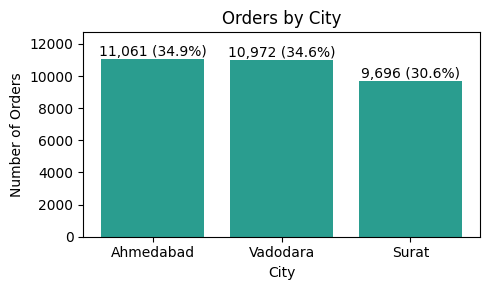

In [89]:
import matplotlib.pyplot as plt

orders_by_city = orders_aggregate.groupby('city')['order_id'].count().sort_values(ascending=False)

total_orders = orders_by_city.sum()

plt.figure(figsize=(5,3))
bars = plt.bar(orders_by_city.index, orders_by_city.values, color='#2a9d8f')

plt.title('Orders by City')
plt.xlabel('City')
plt.ylabel('Number of Orders')

plt.xticks(rotation=0)

plt.ylim(0, orders_by_city.values.max() * 1.15)

for bar, (city, count) in zip(bars, orders_by_city.items()):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{count:,} ({round(count/total_orders*100,1)}%)",
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

### Customer Performance

In [50]:
customer_perf = orders_aggregate.groupby('customer_name').agg({
    'on_time_flag':'mean',
    'in_full_flag':'mean',
    'otif_flag':'mean'
}).rename(columns={
    'on_time_flag':'on_time_pct',
    'in_full_flag':'in_full_pct',
    'otif_flag':'otif_pct'
}).mul(100).round(1).sort_values('otif_pct', ascending=False)

customer_perf.head()

,on_time_pct,in_full_pct,otif_pct
customer_name,,,
Propel Mart,73.6,59.7,40.9
Atlas Stores,71.8,59.8,39.6
Viveks Stores,70.6,60.1,39.4
Expert Mart,72.5,59.8,39.1
Logic Stores,70.8,60.1,38.8


### Product & Category Analysis

In [51]:
product_perf = order_lines.groupby('product_name').agg({
    'on_time_flag':'mean',
    'in_full_flag':'mean',
    'otif_flag':'mean'
}).rename(columns={
    'on_time_flag':'on_time_pct',
    'in_full_flag':'in_full_pct',
    'otif_flag':'otif_pct'
}).mul(100).round(1).sort_values('otif_pct', ascending=False)

product_perf.head(10)

,on_time_pct,in_full_pct,otif_pct
product_name,,,
AM Biscuits 750,72.5,68.0,50.5
AM Milk 500,71.3,67.5,49.6
AM Curd 250,71.1,67.0,49.1
AM Curd 100,71.3,66.7,48.7
AM Milk 100,71.8,65.5,48.6
AM Biscuits 500,72.0,66.1,48.6
AM Butter 100,70.8,66.7,48.1
AM Ghee 150,69.9,66.7,47.9
AM Tea 500,71.5,66.1,47.8


In [52]:
category_perf = order_lines.groupby('category').agg({
    'on_time_flag':'mean',
    'in_full_flag':'mean',
    'otif_flag':'mean'
}).rename(columns={
    'on_time_flag':'on_time_pct',
    'in_full_flag':'in_full_pct',
    'otif_flag':'otif_pct'
}).mul(100).round(1).sort_values('otif_pct', ascending=False)

category_perf

,on_time_pct,in_full_pct,otif_pct
category,,,
Food,72.1,66.4,48.8
Dairy,70.8,65.9,47.8
beverages,71.4,65.5,47.6


### Time Trend Exploration

Use:
- month
- week

In [53]:
monthly_perf = order_lines.groupby(['year','month']).agg({
    'on_time_flag':'mean',
    'in_full_flag':'mean',
    'otif_flag':'mean'
}).rename(columns={
    'on_time_flag':'on_time_pct',
    'in_full_flag':'in_full_pct',
    'otif_flag':'otif_pct'
}).mul(100).round(1).sort_values('month')

monthly_perf

on_time_pct  in_full_pct  otif_pct
year month                                    
2022 3             71.5         65.8      48.0
     4             71.4         65.8      47.8
     5             70.5         66.3      47.6
     6             70.9         65.7      47.9
     7             71.8         65.9      48.6
     8             70.6         66.3      47.8

### Delay Days

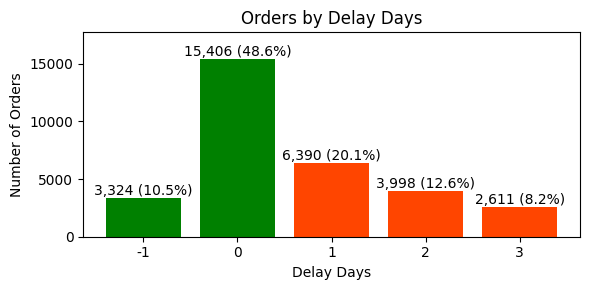

In [59]:
import matplotlib.pyplot as plt

delay_counts = orders_aggregate['delay_days'].value_counts().sort_index()
total_orders = delay_counts.sum()

# colours: green for <=0, red for >0
colors = ['green' if d <= 0 else 'orangered' for d in delay_counts.index]

plt.figure(figsize=(6,3))
bars = plt.bar(delay_counts.index.astype(str), delay_counts.values, color=colors)

plt.title('Orders by Delay Days')
plt.xlabel('Delay Days')
plt.ylabel('Number of Orders')

plt.ylim(0, delay_counts.values.max() * 1.15)

for bar, (delay, count) in zip(bars, delay_counts.items()):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{count:,} ({round(count/total_orders*100,1)}%)",
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

## Delay Days distribution

### Overall delay_days

In [64]:
orders_aggregate['delay_days'].mean().round(2)

np.float64(0.6)

In [71]:
orders_aggregate['delay_days'].describe().to_frame().T

,count,mean,std,min,25%,50%,75%,max
delay_days,31729.0,0.595512,1.093706,-1.0,0.0,0.0,1.0,3.0


### delay_days (only late deliveries)

In [73]:
orders_aggregate.loc[orders_aggregate['delay_days'] > 0, 'delay_days'].describe().to_frame().T

,count,mean,std,min,25%,50%,75%,max
delay_days,12999.0,1.709285,0.779724,1.0,1.0,2.0,2.0,3.0


### Late Delivery Flag distribution

In [83]:
late_dist = (
    orders_aggregate
    .groupby('late_delivery_flag')
    .size()
)

late_dist

late_delivery_flag
False    18730
True     12999
dtype: int64

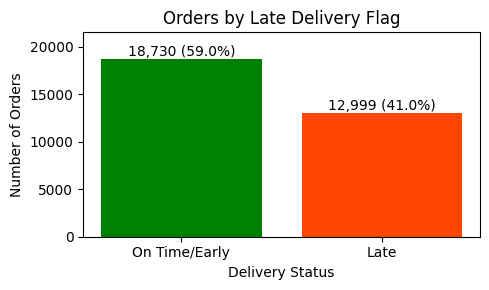

In [84]:
import matplotlib.pyplot as plt

late_counts = orders_aggregate['late_delivery_flag'].value_counts().sort_index()
total_orders = late_counts.sum()

colors = ['green' if i == 0 else 'orangered' for i in late_counts.index]

labels_map = {0: 'On Time/Early', 1: 'Late'}

plt.figure(figsize=(5,3))
bars = plt.bar(
    [labels_map[i] for i in late_counts.index],
    late_counts.values,
    color=colors
)

plt.title('Orders by Late Delivery Flag')
plt.xlabel('Delivery Status')
plt.ylabel('Number of Orders')

plt.ylim(0, late_counts.values.max() * 1.15)

for bar, (flag, count) in zip(bars, late_counts.items()):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{count:,} ({round(count/total_orders*100,1)}%)",
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()